## **Praktikum Mandiri 09 | ML Senin Pagi**

Nama : Rika Rahma

NIM : 011022214

Rombel : TI08 - 2022

### 1. Import Library

In [38]:
# Import Library
# Tahap ini mengimpor semua library Python yang diperlukan untuk analisis data, preprocessing,
# pemodelan, dan evaluasi, sesuai dengan standar praktikum resmi Machine Learning STT-NF.

import pandas as pd                                      # Membaca dan memanipulasi data dalam bentuk DataFrame
import numpy as np                                       # Operasi numerik dan pengolahan array
import matplotlib.pyplot as plt                          # Membuat visualisasi statis
import seaborn as sns                                    # Visualisasi data statistik yang lebih informatif dan menarik
from sklearn.model_selection import train_test_split     # Membagi dataset menjadi data latih dan data uji
from sklearn.preprocessing import StandardScaler         # Menstandarisasi fitur numerik (mean=0, std=1)
from sklearn.naive_bayes import GaussianNB               # Model klasifikasi Naïve Bayes untuk fitur kontinu
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Metrik evaluasi model
from sklearn.model_selection import cross_val_score       # Validasi silang (cross-validation

### 2. Loading Dataset

In [39]:
# Menghubungkan colab dengan Google Drive
from google.colab import drive
drive.mount ('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [40]:
# Memanggil dataset lewat Gdrive
path = '/content/gdrive/MyDrive/Praktikum_ML/praktikum09/data/'

In [41]:
# Dataset yang digunakan adalah Breast Cancer Wisconsin (Diagnostic) dari UCI/Kaggle
# Membaca file CSV menggunakan pandas
cancer_data = pd.read_csv(path + 'breast_cancer_wisconsin.csv')

In [42]:
# Menampilkan 5 baris pertama dataset
print("Lima baris pertama dataset:")
display(cancer_data.head())

Lima baris pertama dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [43]:
# Menampilkan 5 baris terakhir dataset
print("\nLima baris terakhir dataset:")
display(cancer_data.tail())


Lima baris terakhir dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [44]:
# Menampilkan dimensi dataset
print(f"\nDimensi dataset: {cancer_data.shape[0]} baris (entri) dan {cancer_data.shape[1]} kolom")


Dimensi dataset: 569 baris (entri) dan 33 kolom


### 3. Informasi Detail Dataset

In [45]:
print("Informasi detail dataset:")
cancer_data.info()

# - Total 569 entri
# - Terdapat kolom 'id' dan 'Unnamed: 32' yang tidak diperlukan
# - Kolom target: 'diagnosis' (M = malignant, B = benign)
# - Tidak ada missing value pada 31 kolom utama

Informasi detail dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  

### 4. Missing Value & Pembersihan Data

In [46]:
# Cek jumlah missing value per kolom
print("Jumlah missing value per kolom:")
print(cancer_data.isnull().sum())

Jumlah missing value per kolom:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal

In [47]:
# Menghapus kolom yang tidak relevan untuk pemodelan
cancer_data = cancer_data.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

In [48]:
# Cek dimensi setelah pembersihan
print(f"\nDimensi dataset setelah drop kolom tidak relevan: {cancer_data.shape}")


Dimensi dataset setelah drop kolom tidak relevan: (569, 31)


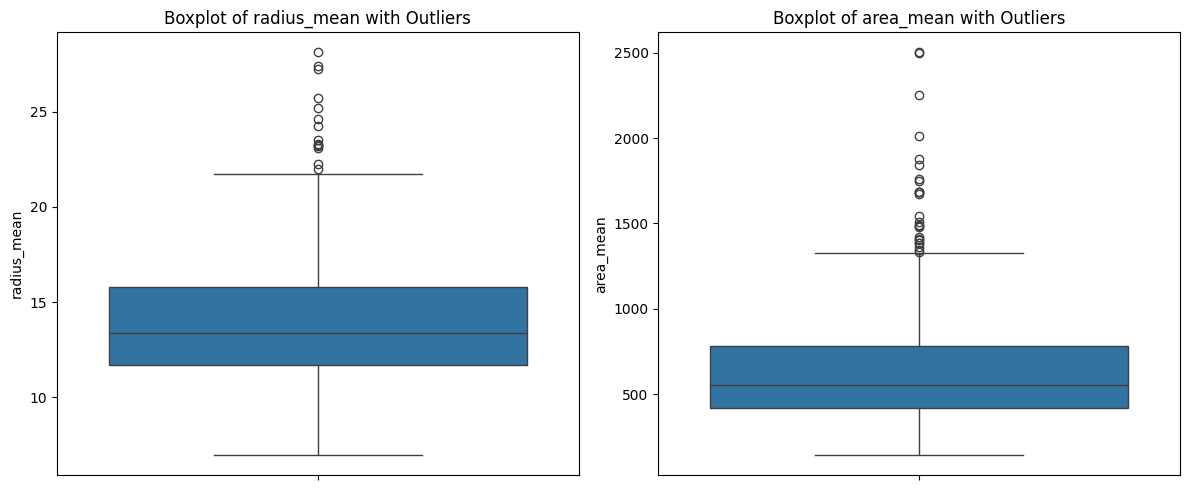

In [49]:
# Visualisasi outliers pada dua fitur utama
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=cancer_data['radius_mean'])
plt.title('Boxplot of radius_mean with Outliers')

plt.subplot(1,2,2)
sns.boxplot(y=cancer_data['area_mean'])
plt.title('Boxplot of area_mean with Outliers')
plt.tight_layout()
plt.show()

### 5. Data Analysis & Encoding Kategorikal

In [50]:
# Statistika deskriptif semua fitur numerik
print("Statistika Deskriptif Fitur Numerik:")
display(cancer_data.describe())

Statistika Deskriptif Fitur Numerik:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [51]:
# Distribusi kelas target sebelum encoding
print("\nDistribusi kelas diagnosis sebelum encoding:")
print(cancer_data['diagnosis'].value_counts())


Distribusi kelas diagnosis sebelum encoding:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [52]:
# Encoding kategorikal: Malignant (M) → 1, Benign (B) → 0
cancer_data['diagnosis'] = cancer_data['diagnosis'].map({'B': 0, 'M': 1})

In [53]:
# Distribusi setelah encoding
print("\nDistribusi kelas diagnosis setelah encoding:")
print(cancer_data['diagnosis'].value_counts())


Distribusi kelas diagnosis setelah encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


/tmp/ipython-input-4003789370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=cancer_data, palette='Set2')


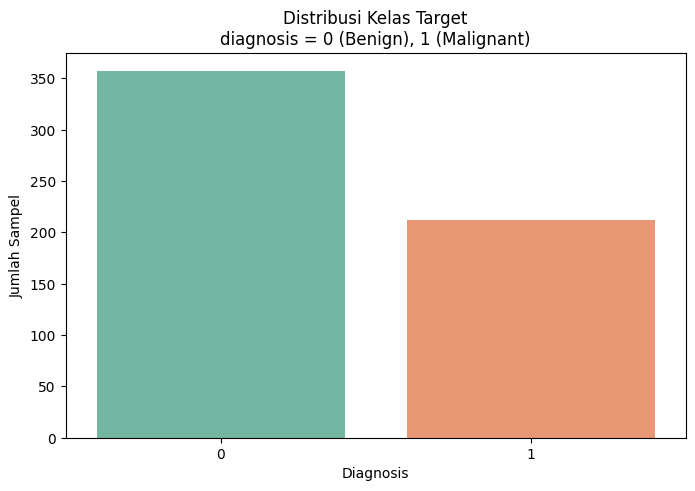

In [54]:
# Visualisasi distribusi kelas target
plt.figure(figsize=(8,5))
sns.countplot(x='diagnosis', data=cancer_data, palette='Set2')
plt.title('Distribusi Kelas Target\ndiagnosis = 0 (Benign), 1 (Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Sampel')
plt.show()

### 6. Visualisasi Hubungan Fitur dengan Target

/tmp/ipython-input-2782421541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=cancer_data, palette='Set1')
/tmp/ipython-input-2782421541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=cancer_data, palette='Set1')
/tmp/ipython-input-2782421541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=col, data=cancer_data, palette='Set1')
/tmp/ipython-input-2782421541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

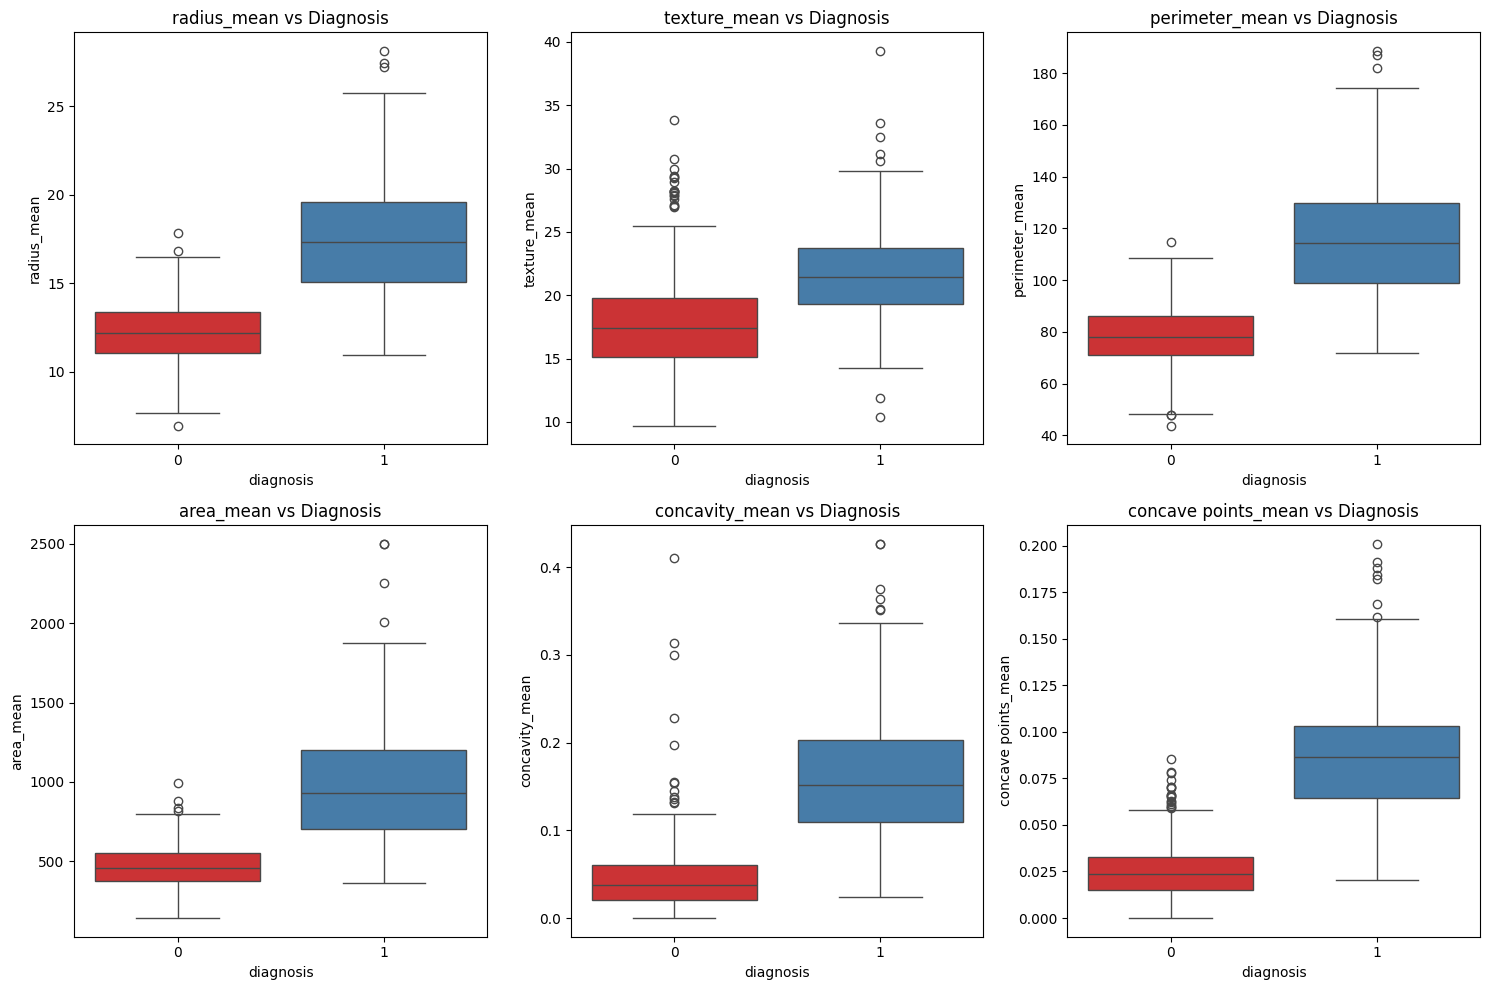

In [55]:
# Menampilkan perbedaan distribusi fitur pada kedua kelas

fitur_visual = ['radius_mean', 'texture_mean', 'perimeter_mean',
                'area_mean', 'concavity_mean', 'concave points_mean']

plt.figure(figsize=(15,10))
for i, col in enumerate(fitur_visual, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='diagnosis', y=col, data=cancer_data, palette='Set1')
    plt.title(f'{col} vs Diagnosis')
plt.tight_layout()
plt.show()

# Insight: Fitur-fitur ukuran dan bentuk tumor cenderung lebih tinggi pada kasus malignant

### 7. Separating, Splitting, and Scaling Data

In [56]:
# Memisahkan fitur dan target, membagi data, serta menstandarisasi fitur

# Pemisahan fitur (X) dan target (y)
X = cancer_data.drop(columns=['diagnosis'])   # Semua kolom kecuali target
y = cancer_data['diagnosis']                  # Kolom target

print(f"Ukuran matriks fitur X : {X.shape}")
print(f"Ukuran vektor target y  : {y.shape}")

Ukuran matriks fitur X : (569, 30)
Ukuran vektor target y  : (569,)


In [57]:
# Splitting data: 80% latih, 20% uji dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nJumlah data latih : {X_train.shape[0]} sampel")
print(f"Jumlah data uji   : {X_test.shape[0]} sampel")


Jumlah data latih : 455 sampel
Jumlah data uji   : 114 sampel


In [58]:
# Standarisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # Fit dan transform pada data latih
X_test_scaled = scaler.transform(X_test)          # Hanya transform pada data uji

### 8. Naive Bayes Classification

In [59]:
# Pembuatan dan pelatihan model Gaussian Naïve Bayes
from sklearn.naive_bayes import GaussianNB

# Membuat instance model
nb_model = GaussianNB()

# Melatih model menggunakan data latih yang telah distandarisasi
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

### 9. Accuracy Score & Evaluation

In [60]:
# Prediksi pada data latih dan data uji
y_train_pred = nb_model.predict(X_train_scaled)
y_test_pred = nb_model.predict(X_test_scaled)

In [61]:
# Menghitung akurasi
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [62]:
print(f"Akurasi pada data latih : {train_accuracy:.4f}")
print(f"Akurasi pada data uji   : {test_accuracy:.4f}")

Akurasi pada data latih : 0.9451
Akurasi pada data uji   : 0.9211


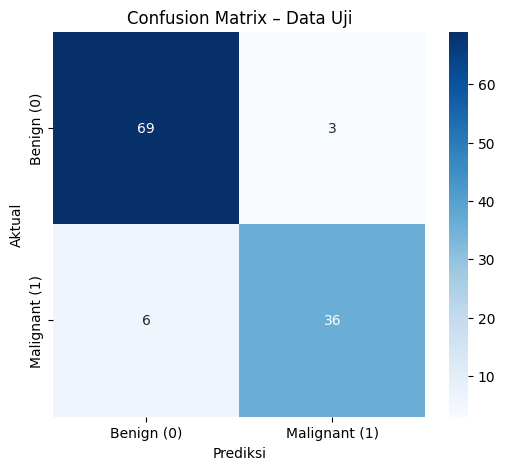

In [63]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix – Data Uji')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [64]:
# Classification Report
print("\nClassification Report (Data Uji):")
print(classification_report(y_test, y_test_pred,
                          target_names=['Benign (0)', 'Malignant (1)']))


Classification Report (Data Uji):
               precision    recall  f1-score   support

   Benign (0)       0.92      0.96      0.94        72
Malignant (1)       0.92      0.86      0.89        42

     accuracy                           0.92       114
    macro avg       0.92      0.91      0.91       114
 weighted avg       0.92      0.92      0.92       114



### 10. Cross Validation (5-Fold)

In [65]:
# Validasi silang
cv_scores = cross_val_score(nb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Hasil Cross-Validation (5-fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"\nRata-rata akurasi : {cv_scores.mean():.4f}")
print(f"Standar deviasi    : {cv_scores.std():.4f}")

Hasil Cross-Validation (5-fold):
Fold 1: 0.9231
Fold 2: 0.9890
Fold 3: 0.9231
Fold 4: 0.9231
Fold 5: 0.9341

Rata-rata akurasi : 0.9385
Standar deviasi    : 0.0256


## Kesimpulan Tugas Mandiri Praktikum 09

1. Dataset Breast Cancer Wisconsin berhasil dimuat, dibersihkan, dan dianalisis secara eksploratori.
2. Tidak terdapat missing value signifikan. Kolom `id` dan `Unnamed: 32` dihapus karena tidak relevan.
3. Target `diagnosis` di-encode menjadi nilai biner (0 = Benign, 1 = Malignant).
4. Seluruh fitur numerik distandarisasi menggunakan `StandardScaler` karena GaussianNB sensitif terhadap skala data.
5. Model Gaussian Naïve Bayes dilatih dan dievaluasi dengan hasil sebagai berikut:
   - Akurasi data latih   : 0.9451
   - Akurasi data uji      : 0.9211
   - Rata-rata Cross-Validation (5-fold) : 0.9385
   - Standar Deviasi : 0.0256
6. Confusion matrix dan classification report menunjukkan performa sangat baik pada kedua kelas.

